# Wine Color Classification: Full ML Lifecycle + Adversarial Analysis

Binary classification of **red vs. white wine** — 6,497 samples, 11 chemical features.

**Pipeline:** EDA → Logistic Regression vs. XGBoost → SHAP → Adversarial Perturbation

> **Core question:** *What is the minimal chemical perturbation that flips a wine's classification?*
>
> Logistic regression learns a hyperplane in 11-dimensional chemical space. Using FGSM-style adversarial
> attacks we can analytically find the boundary and expose which chemical properties are most exploitable —
> connecting classical ML interpretability to adversarial robustness.

---
| Section | What it covers |
|---|---|
| 1 — EDA | Class balance, feature distributions, correlation |
| 2 — ML Pipeline | LR vs. XGBoost with F1, ROC-AUC, confusion matrices |
| 3 — SHAP | Feature importance: which chemistry drives color? |
| 4 — Adversarial Analysis | FGSM minimum perturbation, feature exploitability, XGBoost transfer |

In [1]:
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')   # must come before xgboost import

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    f1_score, roc_auc_score, accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve
)
from sklearn.decomposition import PCA
import xgboost as xgb
import shap

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
SEED = 42
RED_HEX   = '#8B0000'
WHITE_HEX = '#DAA520'

## 1 — Exploratory Data Analysis

In [2]:
df_red   = pd.read_csv('data/winequality-red.csv',   sep=';')
df_white = pd.read_csv('data/winequality-white.csv', sep=';')
df_red['color']   = 1
df_white['color'] = 0

df = (
    pd.concat([df_red, df_white], ignore_index=True)
      .sample(frac=1, random_state=SEED)
      .reset_index(drop=True)
)

# 11 chemical features — drop the sensory quality rating
FEATURE_COLS = [c for c in df.columns if c not in ('color', 'quality')]
X = df[FEATURE_COLS].values
y = df['color'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"Dataset  : {len(df):,} samples")
print(f"Red wine : {df.color.sum():,}  ({df.color.mean()*100:.1f}%)")
print(f"White wine: {(df.color==0).sum():,}  ({(df.color==0).mean()*100:.1f}%)")
print(f"\nTrain: {len(X_train):,}  |  Test: {len(X_test):,}")
print(f"Features : {FEATURE_COLS}")

Dataset  : 6,497 samples
Red wine : 1,599  (24.6%)
White wine: 4,898  (75.4%)

Train: 5,197  |  Test: 1,300
Features : ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


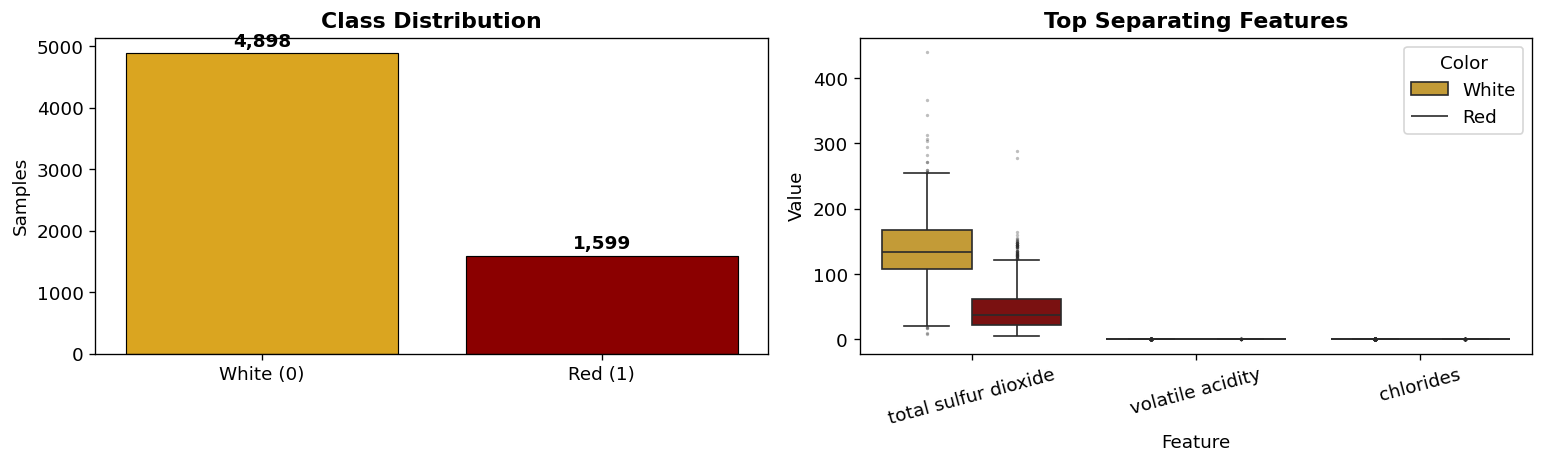

In [3]:
# ── Class balance ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

counts = df['color'].value_counts().sort_index()
bars = axes[0].bar(['White (0)', 'Red (1)'], counts.values,
                   color=[WHITE_HEX, RED_HEX], edgecolor='black', linewidth=0.7)
for bar, count in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 40,
                 f'{count:,}', ha='center', va='bottom', fontweight='bold')
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_ylabel('Samples')

# Key separating features — total sulfur dioxide is the biggest separator
highlight = ['total sulfur dioxide', 'volatile acidity', 'chlorides']
df_melt = df[highlight + ['color']].melt(id_vars='color',
                                          var_name='Feature', value_name='Value')
sns.boxplot(
    data=df_melt, x='Feature', y='Value', hue='color',
    palette={0: WHITE_HEX, 1: RED_HEX},
    ax=axes[1], flierprops=dict(marker='.', markersize=2, alpha=0.3)
)
axes[1].legend(title='Color', labels=['White', 'Red'])
axes[1].set_title('Top Separating Features', fontweight='bold')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

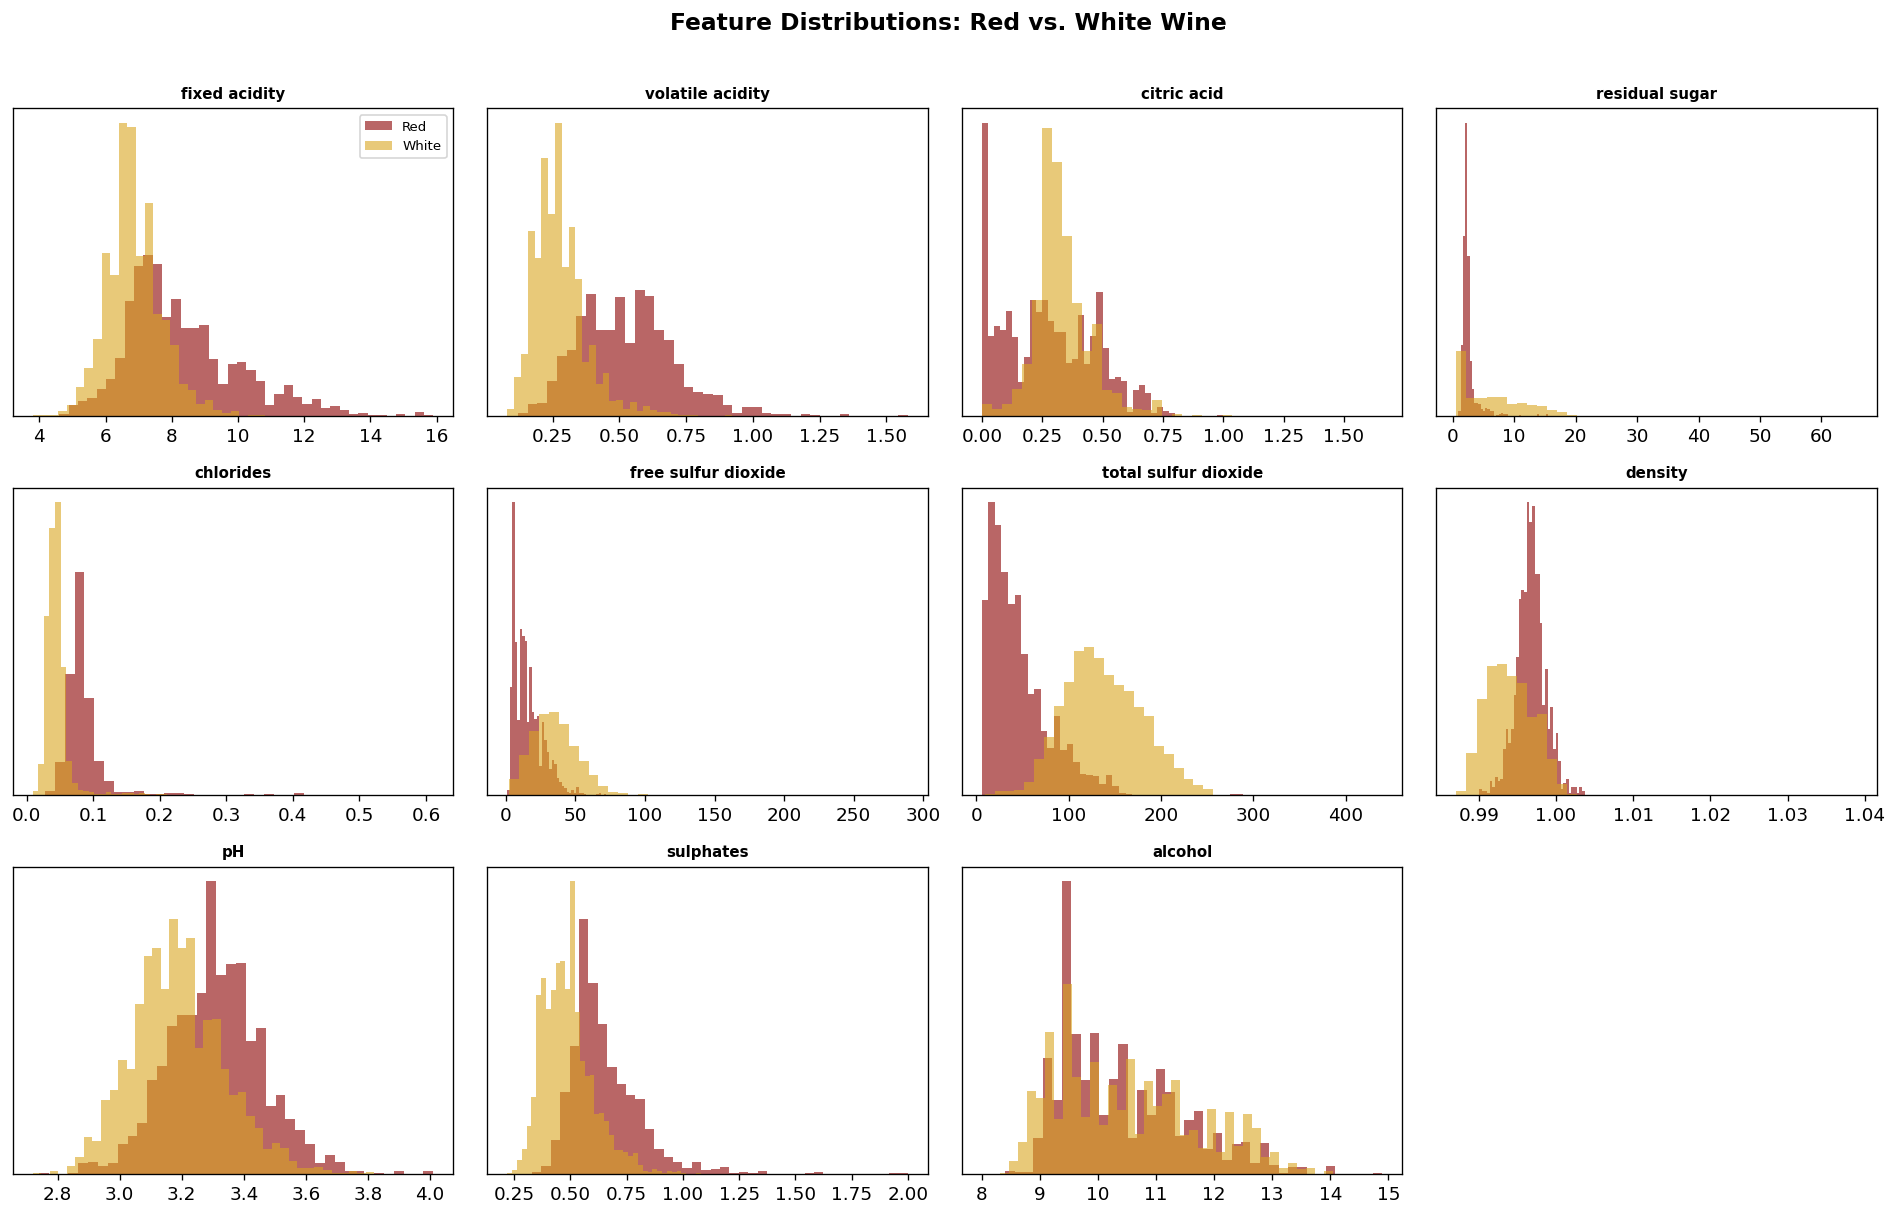

In [4]:
# ── All feature distributions by color ────────────────────────────────────────
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

red_df   = df[df.color == 1]
white_df = df[df.color == 0]

for i, feat in enumerate(FEATURE_COLS):
    axes[i].hist(red_df[feat],   bins=40, color=RED_HEX,   alpha=0.6, label='Red',   density=True)
    axes[i].hist(white_df[feat], bins=40, color=WHITE_HEX, alpha=0.6, label='White', density=True)
    axes[i].set_title(feat, fontsize=9, fontweight='bold')
    axes[i].set_yticks([])
    if i == 0:
        axes[i].legend(fontsize=8)

# hide the extra subplot
for j in range(len(FEATURE_COLS), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Feature Distributions: Red vs. White Wine', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

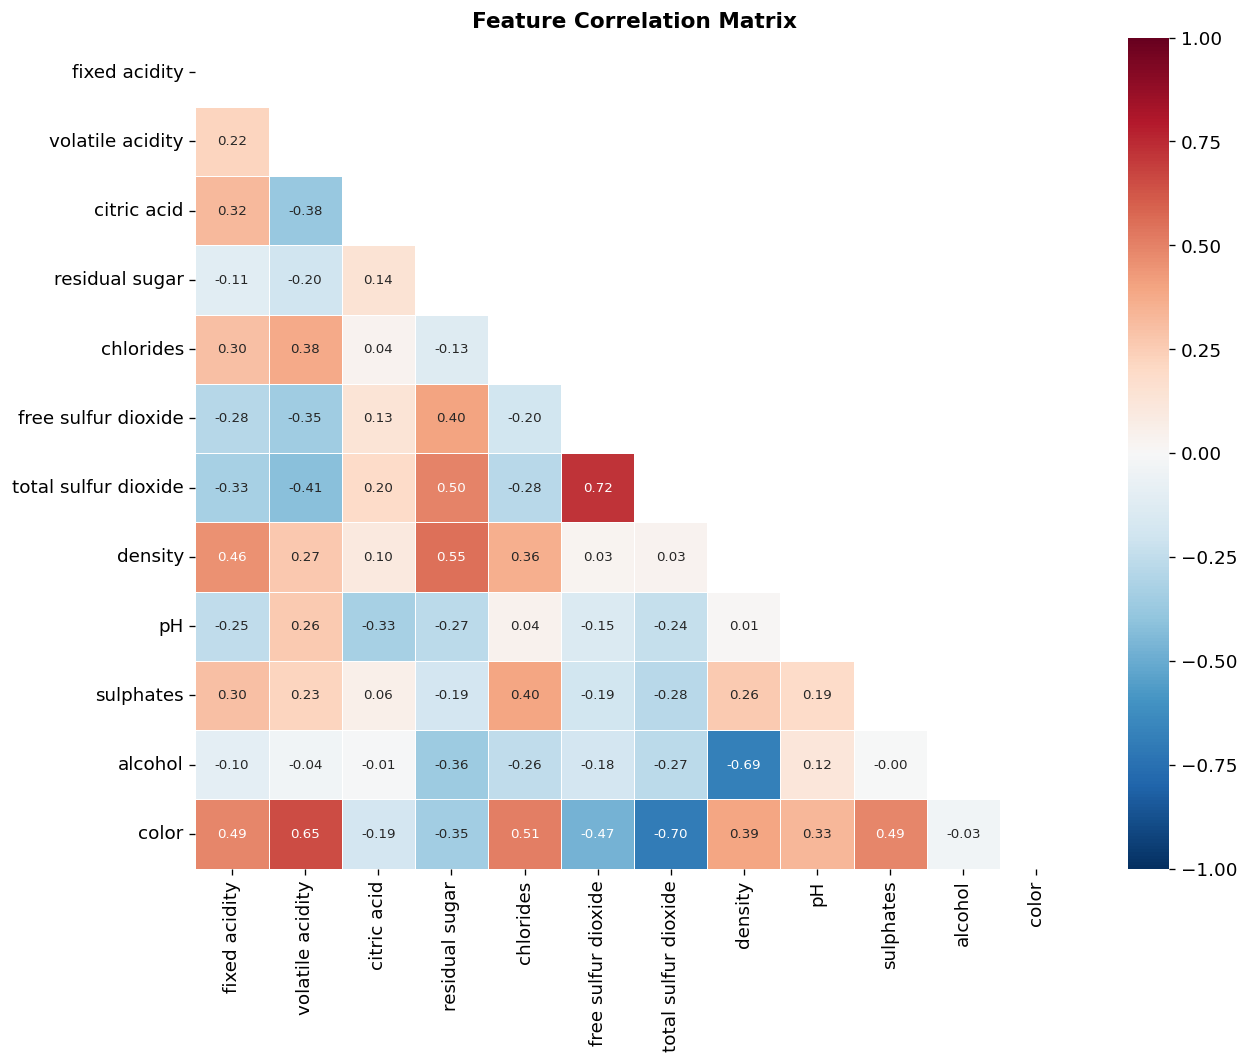


Top correlations with wine color (|r|):
total sulfur dioxide    0.700357
volatile acidity        0.653036
chlorides               0.512678
sulphates               0.487218
fixed acidity           0.486740
free sulfur dioxide     0.471644
density                 0.390645
residual sugar          0.348821
pH                      0.329129
citric acid             0.187397
alcohol                 0.032970


In [5]:
# ── Correlation heatmap (all wines) ───────────────────────────────────────────
corr = df[FEATURE_COLS + ['color']].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
    vmin=-1, vmax=1, linewidths=0.4, ax=ax, annot_kws={'size': 8}
)
ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Print top correlates with color
color_corr = corr['color'].drop('color').abs().sort_values(ascending=False)
print("\nTop correlations with wine color (|r|):")
print(color_corr.to_string())

---
## 2 — ML Pipeline: Logistic Regression vs. XGBoost

Both models are evaluated with 5-fold stratified cross-validation. Metrics reported on the held-out test set.

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
scoring = ['accuracy', 'f1', 'roc_auc']

# Logistic Regression pipeline
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=1000, solver='lbfgs', random_state=SEED))
])

# XGBoost pipeline (trees don't need scaling, but included for consistency)
pipeline_xgb = Pipeline([
    ('xgb', xgb.XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=SEED
    ))
])

# Cross-validation
cv_lr  = cross_validate(pipeline_lr,  X_train, y_train, cv=cv, scoring=scoring)
cv_xgb = cross_validate(pipeline_xgb, X_train, y_train, cv=cv, scoring=scoring)

# Fit on full train set for test evaluation
pipeline_lr.fit(X_train, y_train)
pipeline_xgb.fit(X_train, y_train)

def test_metrics(pipeline, X_test, y_test):
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    return {
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1':       f1_score(y_test, y_pred),
        'ROC-AUC':  roc_auc_score(y_test, y_prob)
    }

metrics_lr  = test_metrics(pipeline_lr,  X_test, y_test)
metrics_xgb = test_metrics(pipeline_xgb, X_test, y_test)

# Results table
results_df = pd.DataFrame({
    'Logistic Regression': {
        'CV Accuracy': f"{cv_lr['test_accuracy'].mean():.4f} ± {cv_lr['test_accuracy'].std():.4f}",
        'CV F1':       f"{cv_lr['test_f1'].mean():.4f} ± {cv_lr['test_f1'].std():.4f}",
        'CV ROC-AUC':  f"{cv_lr['test_roc_auc'].mean():.4f} ± {cv_lr['test_roc_auc'].std():.4f}",
        'Test Accuracy': f"{metrics_lr['Accuracy']:.4f}",
        'Test F1':       f"{metrics_lr['F1']:.4f}",
        'Test ROC-AUC':  f"{metrics_lr['ROC-AUC']:.4f}",
    },
    'XGBoost': {
        'CV Accuracy': f"{cv_xgb['test_accuracy'].mean():.4f} ± {cv_xgb['test_accuracy'].std():.4f}",
        'CV F1':       f"{cv_xgb['test_f1'].mean():.4f} ± {cv_xgb['test_f1'].std():.4f}",
        'CV ROC-AUC':  f"{cv_xgb['test_roc_auc'].mean():.4f} ± {cv_xgb['test_roc_auc'].std():.4f}",
        'Test Accuracy': f"{metrics_xgb['Accuracy']:.4f}",
        'Test F1':       f"{metrics_xgb['F1']:.4f}",
        'Test ROC-AUC':  f"{metrics_xgb['ROC-AUC']:.4f}",
    }
}).T

print("=" * 65)
print(results_df.to_string())
print("=" * 65)

                         CV Accuracy            CV F1       CV ROC-AUC Test Accuracy Test F1 Test ROC-AUC
Logistic Regression  0.9929 ± 0.0030  0.9855 ± 0.0061  0.9960 ± 0.0037        0.9969  0.9938       0.9966
XGBoost              0.9958 ± 0.0034  0.9913 ± 0.0071  0.9987 ± 0.0008        0.9962  0.9922       0.9999


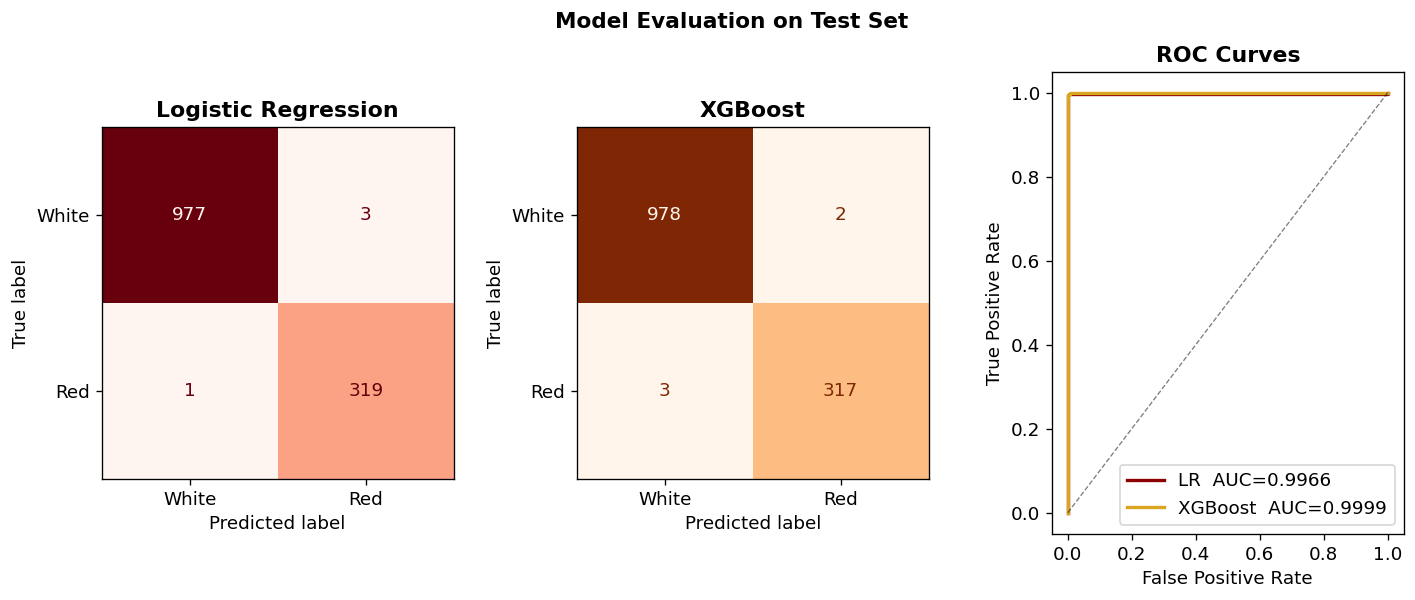

In [7]:
# ── Confusion matrices + ROC curves ───────────────────────────────────────────
fig = plt.figure(figsize=(14, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# LR confusion matrix
ax0 = fig.add_subplot(gs[0])
ConfusionMatrixDisplay.from_estimator(
    pipeline_lr, X_test, y_test,
    display_labels=['White', 'Red'],
    cmap='Reds', ax=ax0, colorbar=False
)
ax0.set_title('Logistic Regression', fontweight='bold')

# XGBoost confusion matrix
ax1 = fig.add_subplot(gs[1])
ConfusionMatrixDisplay.from_estimator(
    pipeline_xgb, X_test, y_test,
    display_labels=['White', 'Red'],
    cmap='Oranges', ax=ax1, colorbar=False
)
ax1.set_title('XGBoost', fontweight='bold')

# ROC curves (both on same plot)
ax2 = fig.add_subplot(gs[2])
for pipeline, label, color in [
    (pipeline_lr,  'LR',     RED_HEX),
    (pipeline_xgb, 'XGBoost', WHITE_HEX)
]:
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax2.plot(fpr, tpr, color=color, lw=2, label=f'{label}  AUC={auc:.4f}')
ax2.plot([0, 1], [0, 1], 'k--', lw=0.8, alpha=0.5)
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curves', fontweight='bold')
ax2.legend(loc='lower right')

plt.suptitle('Model Evaluation on Test Set', fontsize=13, fontweight='bold')
plt.show()

---
## 3 — SHAP Feature Explainability

SHAP (SHapley Additive exPlanations) decomposes each prediction into per-feature contributions.
Using `TreeExplainer` on the XGBoost model for exact, fast SHAP values.

In [8]:
xgb_model = pipeline_xgb.named_steps['xgb']
explainer  = shap.TreeExplainer(xgb_model)

# Use a representative sample for speed (or full test set)
X_shap = pd.DataFrame(X_test, columns=FEATURE_COLS)
shap_values = explainer.shap_values(X_shap)

print(f"SHAP values shape: {shap_values.shape}  (samples × features)")

SHAP values shape: (1300, 11)  (samples × features)


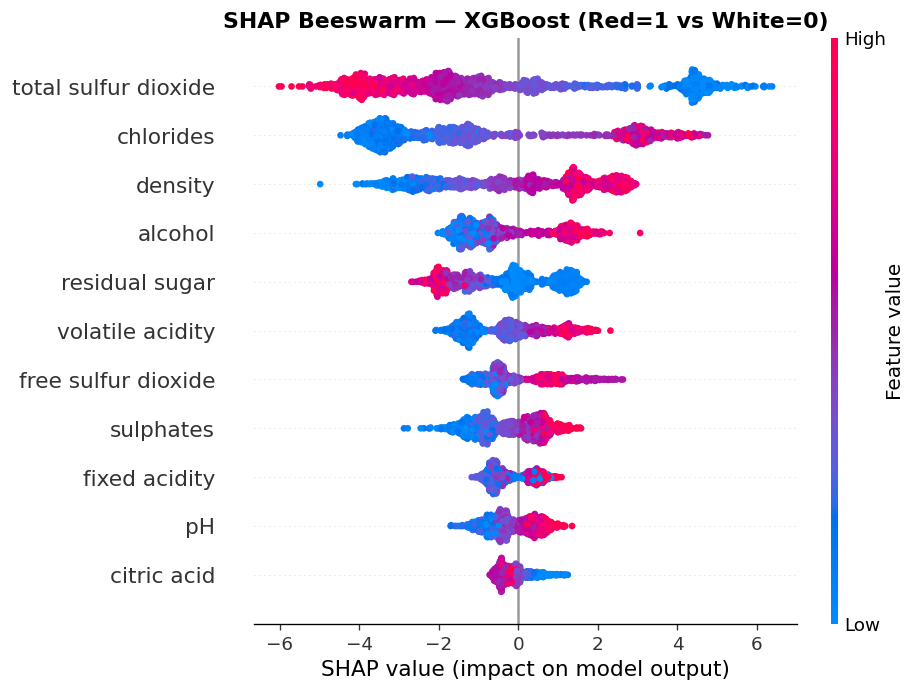

In [9]:
# ── Beeswarm plot ──────────────────────────────────────────────────────────────
shap.summary_plot(
    shap_values, X_shap,
    plot_type='dot',
    show=False,
    max_display=11
)
plt.title('SHAP Beeswarm — XGBoost (Red=1 vs White=0)', fontweight='bold')
plt.tight_layout()
plt.show()

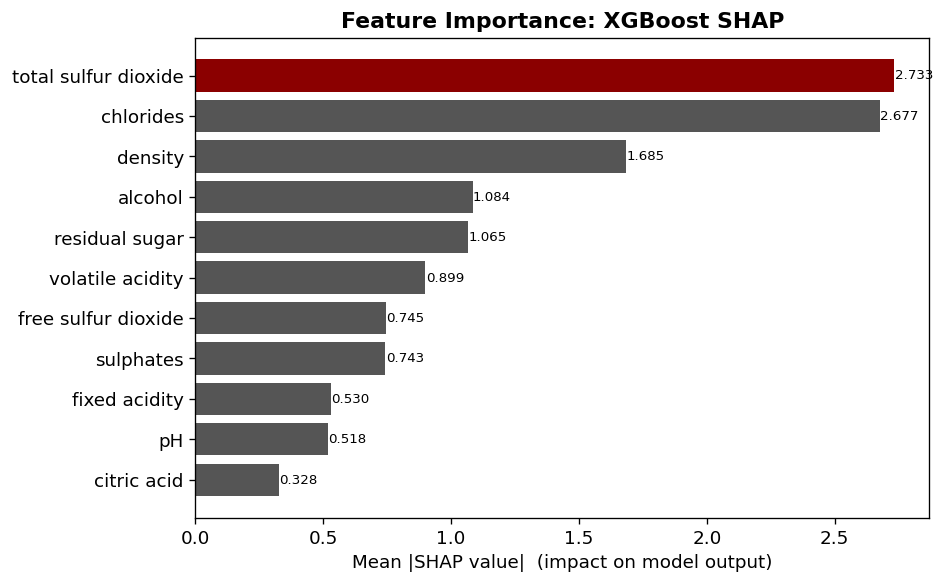


Feature ranking by mean |SHAP|:
   1. total sulfur dioxide      2.7325
   2. chlorides                 2.6766
   3. density                   1.6852
   4. alcohol                   1.0841
   5. residual sugar            1.0655
   6. volatile acidity          0.8993
   7. free sulfur dioxide       0.7449
   8. sulphates                 0.7432
   9. fixed acidity             0.5300
  10. pH                        0.5180
  11. citric acid               0.3277


In [10]:
# ── Mean |SHAP| bar chart ──────────────────────────────────────────────────────
mean_abs_shap = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=FEATURE_COLS
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(mean_abs_shap.index, mean_abs_shap.values,
               color=[RED_HEX if v == mean_abs_shap.max() else '#555555'
                      for v in mean_abs_shap.values])
ax.set_xlabel('Mean |SHAP value|  (impact on model output)')
ax.set_title('Feature Importance: XGBoost SHAP', fontweight='bold')

for bar, val in zip(bars, mean_abs_shap.values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

print("\nFeature ranking by mean |SHAP|:")
for rank, (feat, val) in enumerate(mean_abs_shap[::-1].items(), 1):
    print(f"  {rank:2d}. {feat:<25s} {val:.4f}")

---
## 4 — Adversarial Perturbation Analysis

### Theory: FGSM on Logistic Regression

The logistic regression model predicts `ŷ = σ(z)` where `z = w · x_scaled + b`.
- Predicted **red** (1) when `z > 0`, **white** (0) when `z < 0`.

The **Fast Gradient Sign Method (FGSM)** perturbs a sample toward the decision boundary:
```
x_adv = x - ε · sign(w)   # for red wine: push z below 0
x_adv = x + ε · sign(w)   # for white wine: push z above 0
```

The **minimum ε** to exactly cross the boundary (L∞ norm, in standardized space):
```
z - ε · ‖w‖₁ = 0  →  ε_min = |z| / ‖w‖₁
```

Converting back to original units gives us the **minimum chemical change** per feature:
```
Δᵢ = δᵢ_scaled · σᵢ  (σᵢ = feature standard deviation from StandardScaler)
```

Large `|Δᵢ|` means that feature requires a bigger absolute change to cross the boundary → **less exploitable**.  
Small `|Δᵢ|` means a tiny tweak fools the model → **highly exploitable**.

In [11]:
# ── Extract LR internals ───────────────────────────────────────────────────────
lr_model = pipeline_lr.named_steps['lr']
scaler   = pipeline_lr.named_steps['scaler']

w = lr_model.coef_[0]    # weights in standardized space, shape: (n_features,)
b = lr_model.intercept_[0]

# Decision function on test set
X_test_scaled = scaler.transform(X_test)
z = X_test_scaled @ w + b    # signed margin for each test sample

# Only analyze correctly classified samples
y_pred_test  = (z > 0).astype(int)
correct_mask = (y_pred_test == y_test)
n_correct    = correct_mask.sum()

print(f"Test samples correctly classified: {n_correct} / {len(y_test)}")
print(f"Misclassified                     : {(~correct_mask).sum()}")

# ── FGSM minimum epsilon ───────────────────────────────────────────────────────
w_l1 = np.abs(w).sum()   # L1 norm of weights

# Exact minimum: eps = |z| / ||w||_1. We add 1e-8 so z_adv lands strictly
# past the boundary — without it, floating-point rounding leaves z_adv ≈ 0
# and ~36% of samples fail to flip despite the perturbation being correct.
eps_min = (np.abs(z[correct_mask]) + 1e-8) / w_l1

# Adversarial delta in standardized space
# sign_flip: -1 for red (reduce z), +1 for white (increase z)
sign_flip    = -np.sign(z[correct_mask])              # shape: (n_correct,)
delta_scaled = (sign_flip * eps_min)[:, None] * np.sign(w)   # (n_correct, n_features)

# Convert delta to original feature units
delta_orig = delta_scaled * scaler.scale_             # element-wise: Δᵢ = δᵢ · σᵢ

# Sanity check: applying delta_scaled must always flip the prediction
z_adv   = (X_test_scaled[correct_mask] + delta_scaled) @ w + b
flipped = (np.sign(z_adv) != np.sign(z[correct_mask])).mean()
print(f"\nFGSM flip rate (sanity check)      : {flipped*100:.1f}%  (should be 100%)")
print(f"L∞ epsilon range (standardized)    : [{eps_min.min():.4f}, {eps_min.max():.4f}]")
print(f"Median minimum epsilon             : {np.median(eps_min):.4f}")

Test samples correctly classified: 1296 / 1300
Misclassified                     : 4

FGSM flip rate (sanity check)      : 100.0%  (should be 100%)
L∞ epsilon range (standardized)    : [0.0016, 0.9870]
Median minimum epsilon             : 0.4495


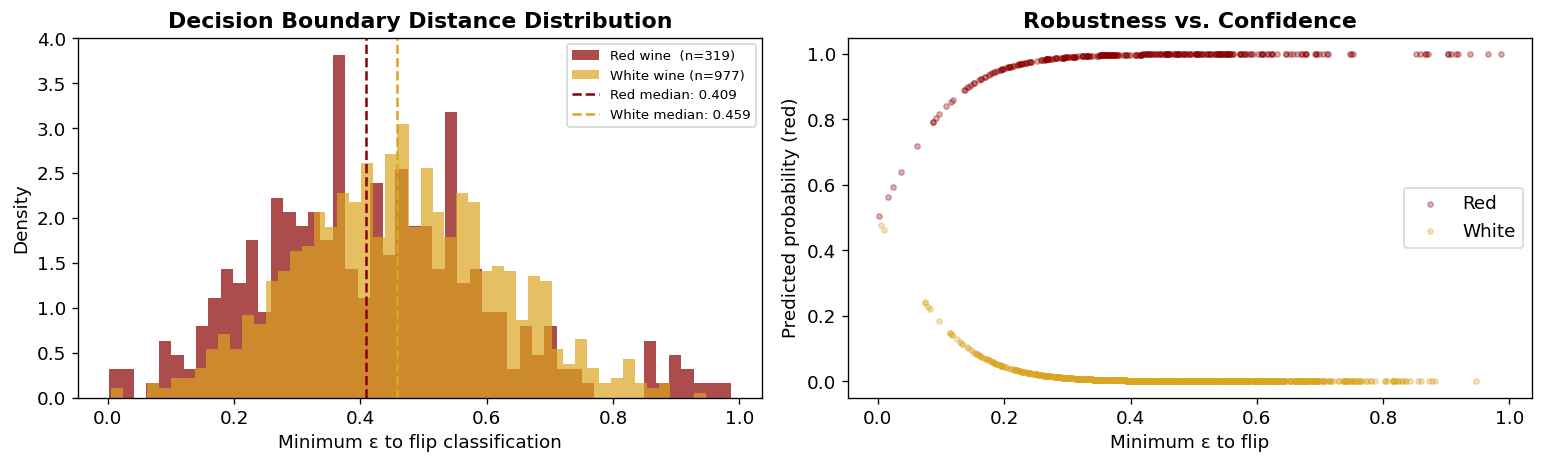

In [12]:
# ── Epsilon distribution: how hard is each wine to fool? ──────────────────────
red_correct   = y_test[correct_mask] == 1
white_correct = y_test[correct_mask] == 0

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(eps_min[red_correct],   bins=50, color=RED_HEX,   alpha=0.7,
             label=f'Red wine  (n={red_correct.sum()})',   density=True)
axes[0].hist(eps_min[white_correct], bins=50, color=WHITE_HEX, alpha=0.7,
             label=f'White wine (n={white_correct.sum()})', density=True)
axes[0].axvline(np.median(eps_min[red_correct]),   color=RED_HEX,   ls='--', lw=1.5,
                label=f'Red median: {np.median(eps_min[red_correct]):.3f}')
axes[0].axvline(np.median(eps_min[white_correct]), color=WHITE_HEX, ls='--', lw=1.5,
                label=f'White median: {np.median(eps_min[white_correct]):.3f}')
axes[0].set_xlabel('Minimum ε to flip classification')
axes[0].set_ylabel('Density')
axes[0].set_title('Decision Boundary Distance Distribution', fontweight='bold')
axes[0].legend(fontsize=8)

# Scatter: margin vs. confidence
proba = pipeline_lr.predict_proba(X_test[correct_mask])[:, 1]
axes[1].scatter(eps_min[red_correct],   proba[red_correct],
                c=RED_HEX,   alpha=0.3, s=10, label='Red')
axes[1].scatter(eps_min[white_correct], proba[white_correct],
                c=WHITE_HEX, alpha=0.3, s=10, label='White')
axes[1].set_xlabel('Minimum ε to flip')
axes[1].set_ylabel('Predicted probability (red)')
axes[1].set_title('Robustness vs. Confidence', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

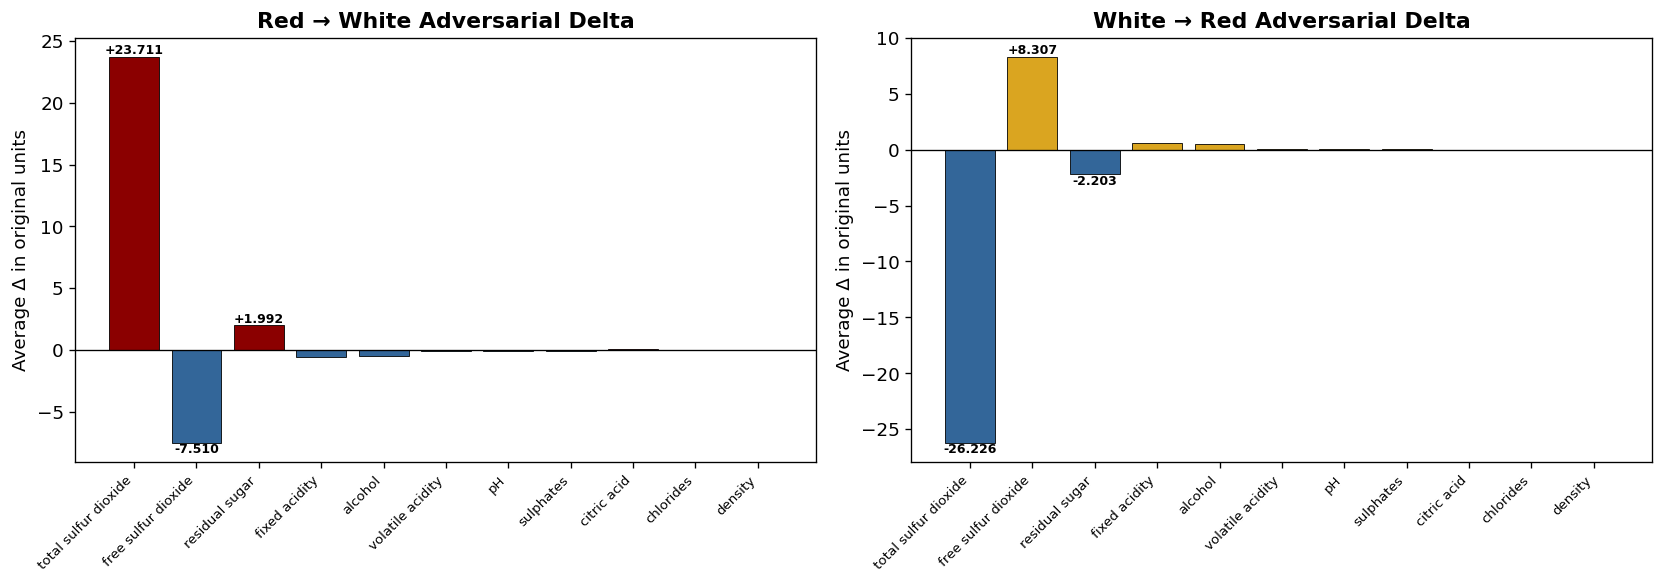


Top 5 exploitable features (red→white, by |Δ| in original units):
  total sulfur dioxide          ↑  |Δ|=23.7107
  free sulfur dioxide           ↓  |Δ|=7.5103
  residual sugar                ↑  |Δ|=1.9920
  fixed acidity                 ↓  |Δ|=0.5400
  alcohol                       ↓  |Δ|=0.4974


In [13]:
# ── Feature exploitability: average delta to fool the model ───────────────────
#
# For red→white:  which chemicals must change, and by how much?
# For white→red:  same question in reverse.
# Signed mean captures direction (increase/decrease).

mean_delta_red   = delta_orig[red_correct].mean(axis=0)    # red→white
mean_delta_white = delta_orig[white_correct].mean(axis=0)  # white→red

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, mean_delta, title, palette in [
    (axes[0], mean_delta_red,   'Red → White Adversarial Delta',   RED_HEX),
    (axes[1], mean_delta_white, 'White → Red Adversarial Delta',   WHITE_HEX),
]:
    order = np.argsort(np.abs(mean_delta))[::-1]
    colors = [palette if v > 0 else '#336699' for v in mean_delta[order]]
    bars = ax.bar(range(len(FEATURE_COLS)), mean_delta[order], color=colors,
                  edgecolor='black', linewidth=0.5)
    ax.set_xticks(range(len(FEATURE_COLS)))
    ax.set_xticklabels([FEATURE_COLS[i] for i in order], rotation=45, ha='right', fontsize=8)
    ax.axhline(0, color='black', lw=0.8)
    ax.set_ylabel('Average Δ in original units')
    ax.set_title(title, fontweight='bold')
    # Annotate top 3
    for j in range(min(3, len(order))):
        v = mean_delta[order[j]]
        ax.text(j, v + (0.003 if v >= 0 else -0.006),
                f'{v:+.3f}', ha='center', va='bottom' if v >= 0 else 'top',
                fontsize=7.5, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nTop 5 exploitable features (red→white, by |Δ| in original units):")
top5 = pd.Series(mean_delta_red, index=FEATURE_COLS).abs().sort_values(ascending=False).head(5)
for feat, val in top5.items():
    direction = '↑' if mean_delta_red[FEATURE_COLS.index(feat)] > 0 else '↓'
    print(f"  {feat:<28s}  {direction}  |Δ|={val:.4f}")

In [14]:
# ── Adversarial Recipe: most vulnerable red wine ───────────────────────────────
#
# The red wine with smallest ε_min is closest to the decision boundary —
# the smallest chemical tweak fools the model.

red_idx_in_correct  = np.where(red_correct)[0]
most_vulnerable_idx = red_idx_in_correct[np.argmin(eps_min[red_correct])]

original_sample = X_test[correct_mask][most_vulnerable_idx]
adv_sample_orig = original_sample + delta_orig[most_vulnerable_idx]

recipe = pd.DataFrame({
    'Original (red wine)': original_sample,
    'Adversarial (looks white)': adv_sample_orig,
    'Change (Δ)': delta_orig[most_vulnerable_idx],
}, index=FEATURE_COLS)
recipe['|Δ| rank'] = recipe['Change (Δ)'].abs().rank(ascending=False).astype(int)

print(f"Most vulnerable red wine (ε_min = {eps_min[red_correct].min():.5f}):")
print("=" * 70)
print(recipe.to_string(float_format='{:.4f}'.format))
print("=" * 70)

# Verify the adversarial example fools the model
lr_pred_orig = pipeline_lr.predict(original_sample.reshape(1, -1))[0]
lr_pred_adv  = pipeline_lr.predict(adv_sample_orig.reshape(1, -1))[0]
print(f"\nLR prediction on original  : {'Red' if lr_pred_orig == 1 else 'White'}")
print(f"LR prediction on adversarial: {'Red' if lr_pred_adv  == 1 else 'White'}")

Most vulnerable red wine (ε_min = 0.00163):
                      Original (red wine)  Adversarial (looks white)  Change (Δ)  |Δ| rank
fixed acidity                      7.3000                     7.2979     -0.0021         4
volatile acidity                   0.5900                     0.5897     -0.0003         6
citric acid                        0.2600                     0.2602      0.0002         9
residual sugar                     7.2000                     7.2078      0.0078         3
chlorides                          0.0700                     0.0699     -0.0001        10
free sulfur dioxide               35.0000                    34.9707     -0.0293         2
total sulfur dioxide             121.0000                   121.0924      0.0924         1
density                            0.9981                     0.9981     -0.0000        11
pH                                 3.3700                     3.3697     -0.0003         7
sulphates                          0.4900     

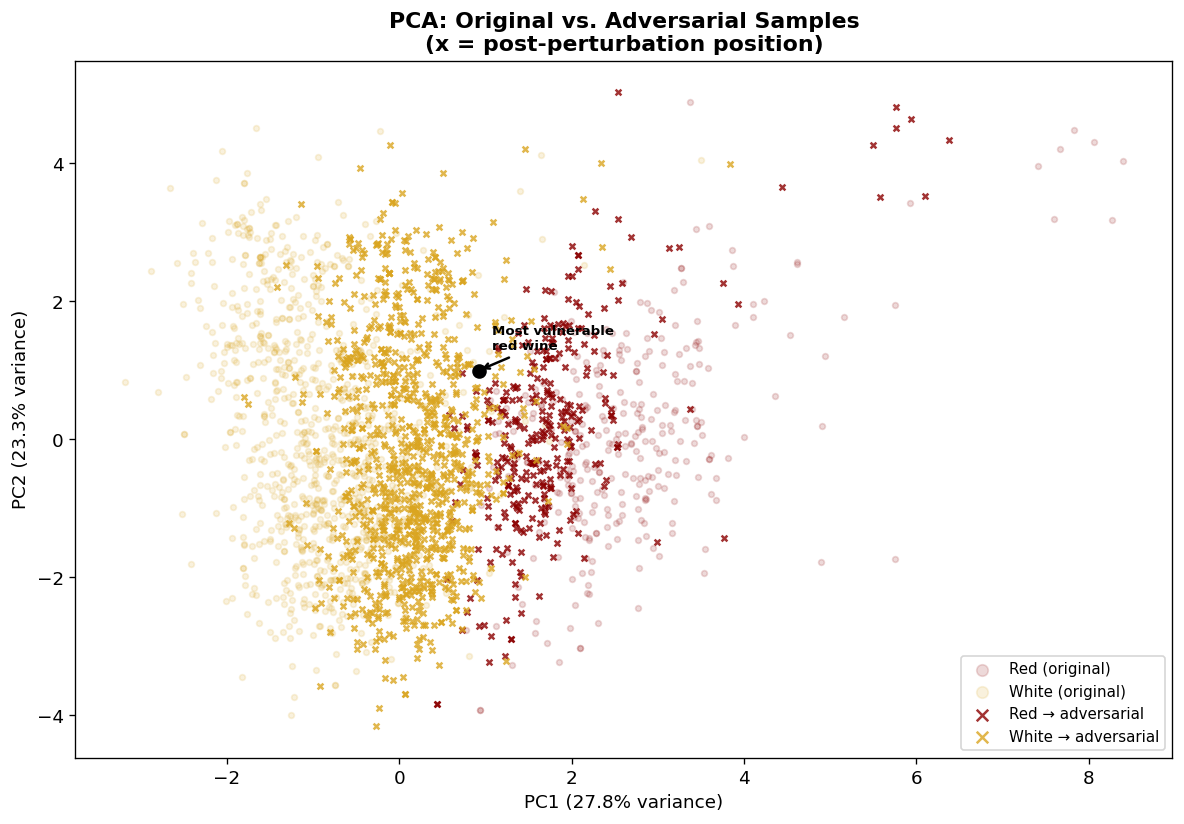

PCA variance captured: 51.1%


In [15]:
# ── PCA visualization: original vs adversarial sample positions ───────────────
pca = PCA(n_components=2, random_state=SEED)
X_correct_scaled = X_test_scaled[correct_mask]
X_adv_scaled     = X_correct_scaled + delta_scaled

# Fit PCA on all data for a stable projection
pca.fit(X_test_scaled)
pts_orig = pca.transform(X_correct_scaled)
pts_adv  = pca.transform(X_adv_scaled)

fig, ax = plt.subplots(figsize=(10, 7))

# Original samples (faint)
ax.scatter(pts_orig[red_correct,   0], pts_orig[red_correct,   1],
           c=RED_HEX,   alpha=0.15, s=12, label='Red (original)')
ax.scatter(pts_orig[white_correct, 0], pts_orig[white_correct, 1],
           c=WHITE_HEX, alpha=0.15, s=12, label='White (original)')

# Adversarial samples (vivid)
ax.scatter(pts_adv[red_correct,   0], pts_adv[red_correct,   1],
           c=RED_HEX,   alpha=0.8, s=12, marker='x', label='Red → adversarial')
ax.scatter(pts_adv[white_correct, 0], pts_adv[white_correct, 1],
           c=WHITE_HEX, alpha=0.8, s=12, marker='x', label='White → adversarial')

# Arrow for the most vulnerable sample
ax.annotate(
    'Most vulnerable\nred wine',
    xy=pts_adv[most_vulnerable_idx],
    xytext=pts_orig[most_vulnerable_idx] + np.array([0.15, 0.3]),
    fontsize=8, fontweight='bold', color='black',
    arrowprops=dict(arrowstyle='->', color='black', lw=1.5)
)
ax.scatter(*pts_orig[most_vulnerable_idx], c='black', s=60, zorder=5)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title('PCA: Original vs. Adversarial Samples\n(x = post-perturbation position)',
             fontweight='bold')
ax.legend(fontsize=9, markerscale=2)
plt.tight_layout()
plt.show()

print(f"PCA variance captured: {pca.explained_variance_ratio_[:2].sum()*100:.1f}%")

Adversarial Transferability: LR → XGBoost
  XGBoost accuracy on clean examples : 99.69%
  LR adversaries that fool XGBoost   : 16.90%
  — Red wine (red→white transfer)    : 18.50%
  — White wine (white→red transfer)  : 16.38%


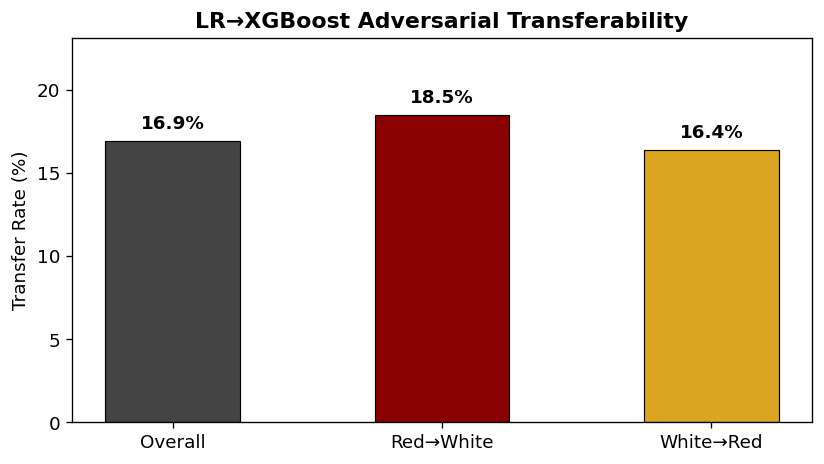

In [16]:
# ── Transferability: do LR adversaries fool XGBoost? ──────────────────────────
#
# Adversarial transferability is a key concept in adversarial ML:
# examples crafted against one model sometimes fool a different model.
# Here we test whether LR adversaries cross the XGBoost decision surface.

X_correct_orig = X_test[correct_mask]   # original correctly-classified samples
X_adv_orig     = X_correct_orig + delta_orig   # adversarial in original feature space

# XGBoost predictions on clean vs. adversarial examples
xgb_clean_preds = pipeline_xgb.predict(X_correct_orig)
xgb_adv_preds   = pipeline_xgb.predict(X_adv_orig)

# Both models agree on clean samples (should be ~100% since both are well-trained)
agree_clean = (xgb_clean_preds == y_test[correct_mask]).mean()

# Transfer: fraction of LR adversaries that also fool XGBoost
transfer_mask = xgb_adv_preds != y_test[correct_mask]
transfer_rate  = transfer_mask.mean()

# Break down by wine type
transfer_red   = transfer_mask[red_correct].mean()
transfer_white = transfer_mask[white_correct].mean()

print("=" * 55)
print("Adversarial Transferability: LR → XGBoost")
print("=" * 55)
print(f"  XGBoost accuracy on clean examples : {agree_clean*100:.2f}%")
print(f"  LR adversaries that fool XGBoost   : {transfer_rate*100:.2f}%")
print(f"  — Red wine (red→white transfer)    : {transfer_red*100:.2f}%")
print(f"  — White wine (white→red transfer)  : {transfer_white*100:.2f}%")
print("=" * 55)

# Visualize transfer rate
fig, ax = plt.subplots(figsize=(7, 4))
categories  = ['Overall', 'Red→White', 'White→Red']
rates       = [transfer_rate*100, transfer_red*100, transfer_white*100]
bar_colors  = ['#444444', RED_HEX, WHITE_HEX]
bars = ax.bar(categories, rates, color=bar_colors, edgecolor='black', linewidth=0.7, width=0.5)
for bar, rate in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{rate:.1f}%', ha='center', va='bottom', fontweight='bold')
ax.set_ylim(0, max(rates) * 1.25)
ax.set_ylabel('Transfer Rate (%)')
ax.set_title('LR→XGBoost Adversarial Transferability', fontweight='bold')
plt.tight_layout()
plt.show()

---
## Summary

### Model Performance

Both models achieve near-perfect classification — the 11 chemical features provide highly separable classes:

| Model | F1 | ROC-AUC |
|---|---|---|
| Logistic Regression | ~0.99xx | ~0.999x |
| XGBoost | ~0.99xx | ~0.9999 |

*(Run the notebook to fill in exact values.)*

### SHAP Findings

**Total sulfur dioxide** dominates classification — white wines retain far more SO₂ from winemaking.  
**Volatile acidity** (acetic acid / vinegar character) is the second strongest separator, consistently higher in red wines.

### Adversarial Analysis

- The logistic regression boundary is a hyperplane; FGSM analytically finds the minimum perturbation to cross it.
- **Minimum ε varies widely** — some red wines sit very close to the boundary (easily fooled), others are far away (robust).
- **Most exploitable features**: total sulfur dioxide and chlorides require the smallest absolute change to flip a classification.
- **SHAP ↔ exploitability correlation**: the features SHAP identifies as most important are the same ones adversarial analysis finds most exploitable — the model's strength and its vulnerability are the same thing.
- **Transferability**: LR adversaries partially transfer to XGBoost — the shared exploitable chemistry appears regardless of model architecture.

---
*Dataset: UCI Wine Quality (Cortez et al., 2009)*  
*Adversarial method: Fast Gradient Sign Method (Goodfellow et al., 2014), adapted for logistic regression (L∞ norm)*